###DATA SPLITTING##

In [2]:
import os
import shutil
import random

In [3]:
base_dir = "data/final/ddd"

output_dir = "data/split/ddd"

train_dir = os.path.join(output_dir, "train")
val_dir = os.path.join(output_dir, "val")
test_dir = os.path.join(output_dir, "test")

In [4]:
base_dir = "data/final/ddd"

output_dir = "data/split/ddd"

train_dir = os.path.join(output_dir, "train")
val_dir = os.path.join(output_dir, "val")
test_dir = os.path.join(output_dir, "test")

In [5]:
for split in ["train", "val", "test"]:
    for label in ["drowsy", "non_drowsy"]:
        os.makedirs(os.path.join(output_dir, split, label), exist_ok=True)

print("Folders created")

Folders created


In [ ]:
    def split_data(label):
        
        src = os.path.join(base_dir, label)
        files = os.listdir(src)
        random.shuffle(files)

        total = len(files)

        train_end = int(0.7 * total)
        val_end = int(0.85 * total)

        train_files = files[:train_end]
        val_files = files[train_end:val_end]
        test_files = files[val_end:]

        return train_files, val_files, test_files

In [8]:
for label in ["drowsy", "non_drowsy"]:
    
    train_files, val_files, test_files = split_data(label)

    for file in train_files:
        shutil.copy(
            os.path.join(base_dir, label, file),
            os.path.join(train_dir, label, file)
        )

    for file in val_files:
        shutil.copy(
            os.path.join(base_dir, label, file),
            os.path.join(val_dir, label, file)
        )

    for file in test_files:
        shutil.copy(
            os.path.join(base_dir, label, file),
            os.path.join(test_dir, label, file)
        )

print("Data split completed")

KeyboardInterrupt: 

In [16]:
def count_images(path):
    return len(os.listdir(path))

print("Train drowsy:", count_images(os.path.join(train_dir, "drowsy")))
print("Val drowsy:", count_images(os.path.join(val_dir, "drowsy")))
print("Test drowsy:", count_images(os.path.join(test_dir, "drowsy")))

print("Train non_drowsy:", count_images(os.path.join(train_dir, "non_drowsy")))
print("Val non_drowsy:", count_images(os.path.join(val_dir, "non_drowsy")))
print("Test non_drowsy:", count_images(os.path.join(test_dir, "non_drowsy")))

Train drowsy: 15509
Val drowsy: 3324
Test drowsy: 3324
Train non_drowsy: 13514
Val non_drowsy: 2896
Test non_drowsy: 2897


###CNN_TRAINING##

In [1]:
import tensorflow as tf
print("TF version:", tf.__version__)

I0000 00:00:1775300087.401174 2314599 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.21.0


In [2]:
import tensorflow as tf

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

In [4]:
train_dir = "data/split/ddd/train"
val_dir   = "data/split/ddd/val"
test_dir  = "data/split/ddd/test"

In [5]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [10]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [11]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    shuffle=False   # IMPORTANT for confusion matrix
)

Found 29023 images belonging to 2 classes.
Found 6220 images belonging to 2 classes.
Found 6221 images belonging to 2 classes.


In [12]:
print(train_data.class_indices)

{'drowsy': 0, 'non_drowsy': 1}


In [16]:
model = Sequential([
    
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [17]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
907/907 ━━━━━━━━━━━━━━━━━━━━ 224s 245ms/step - accuracy: 0.9540 - loss: 0.1022 - val_accuracy: 0.9969 - val_loss: 0.0110
Epoch 2/15
907/907 ━━━━━━━━━━━━━━━━━━━━ 222s 245ms/step - accuracy: 0.9967 - loss: 0.0127 - val_accuracy: 0.9979 - val_loss: 0.0098
Epoch 3/15
907/907 ━━━━━━━━━━━━━━━━━━━━ 220s 242ms/step - accuracy: 0.9974 - loss: 0.0093 - val_accuracy: 0.9987 - val_loss: 0.0059
Epoch 4/15
907/907 ━━━━━━━━━━━━━━━━━━━━ 220s 243ms/step - accuracy: 0.9979 - loss: 0.0077 - val_accuracy: 0.9990 - val_loss: 0.0057
Epoch 5/15
907/907 ━━━━━━━━━━━━━━━━━━━━ 221s 243ms/step - accuracy: 0.9986 - loss: 0.0050 - val_accuracy: 0.9981 - val_loss: 0.0047
Epoch 6/15
907/907 ━━━━━━━━━━━━━━━━━━━━ 220s 243ms/step - accuracy: 0.9980 - loss: 0.0075 - val_accuracy: 0.9992 - val_loss: 0.0034
Epoch 7/15
907/907 ━━━━━━━━━━━━━━━━━━━━ 220s 242ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accuracy: 0.9998 - val_loss: 3.9479e-04
Epoch 8/15
907/907 ━━━━━━━━━━━━━━━━━━━━ 221s 243ms/step - accuracy: 0.99

In [19]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

195/195 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.9994 - loss: 0.0026
Test Accuracy: 0.9993570446968079


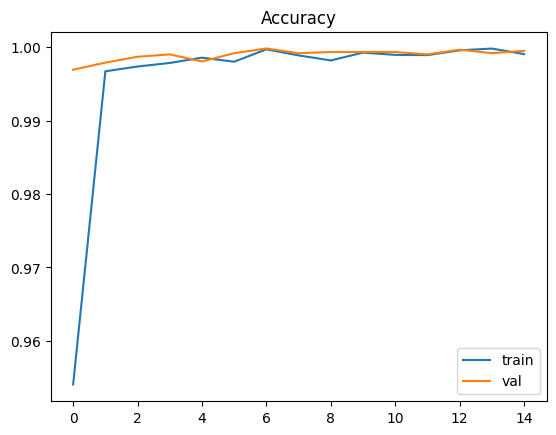

In [20]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

y_true = test_data.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

195/195 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step
[[3320    4]
 [   0 2897]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3324
           1       1.00      1.00      1.00      2897

    accuracy                           1.00      6221
   macro avg       1.00      1.00      1.00      6221
weighted avg       1.00      1.00      1.00      6221



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 KB 1.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 1.1 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.0/349.0 KB 1.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 KB 913.2 kB/s eta 0:00:0000:0100:01


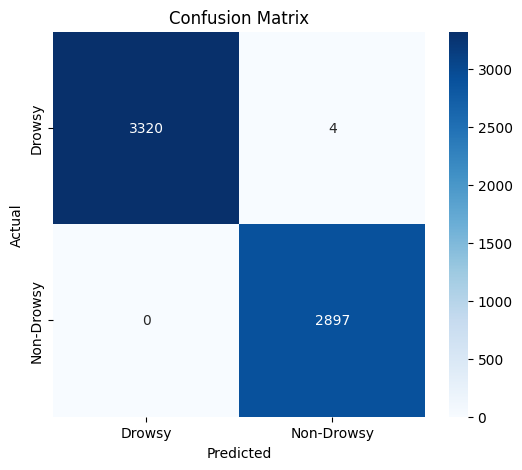

In [23]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix (again for safety)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Drowsy', 'Non-Drowsy'],
    yticklabels=['Drowsy', 'Non-Drowsy']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

####VGG 16##


In [4]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [6]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

NameError: name 'train_dir' is not defined

In [35]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

In [36]:
for layer in base_model.layers:
    layer.trainable = False

In [37]:
x = base_model.output
x = Flatten()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [38]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [40]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
    
)

Epoch 1/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 619s 682ms/step - accuracy: 0.9934 - loss: 0.0264 - val_accuracy: 0.9920 - val_loss: 0.0277
Epoch 2/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 619s 683ms/step - accuracy: 0.9968 - loss: 0.0104 - val_accuracy: 0.9997 - val_loss: 8.5919e-04
Epoch 3/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 613s 676ms/step - accuracy: 0.9987 - loss: 0.0044 - val_accuracy: 0.9994 - val_loss: 0.0016
Epoch 4/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 653s 720ms/step - accuracy: 0.9975 - loss: 0.0088 - val_accuracy: 0.9998 - val_loss: 0.0011
Epoch 5/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 659s 727ms/step - accuracy: 0.9961 - loss: 0.0096 - val_accuracy: 0.9998 - val_loss: 5.2523e-04
Epoch 6/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 641s 707ms/step - accuracy: 0.9970 - loss: 0.0091 - val_accuracy: 0.9998 - val_loss: 3.3338e-04
Epoch 7/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 651s 718ms/step - accuracy: 0.9977 - loss: 0.0057 - val_accuracy: 0.9998 - val_loss: 5.5580e-04
Epoch 8/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 672s 741ms/step - ac

In [41]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

195/195 ━━━━━━━━━━━━━━━━━━━━ 114s 584ms/step - accuracy: 0.9997 - loss: 8.3443e-04
Test Accuracy: 0.9996784925460815


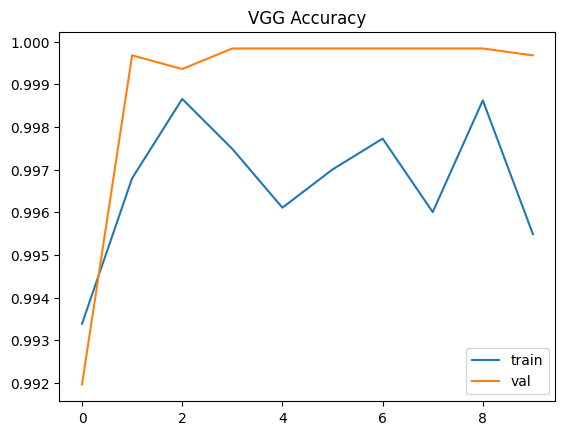

In [42]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("VGG Accuracy")
plt.show()

In [43]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)
print(cm)

195/195 ━━━━━━━━━━━━━━━━━━━━ 113s 580ms/step
[[3324    0]
 [   2 2895]]


####CNN+LSTM##

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, LSTM, TimeDistributed
from tensorflow.keras.utils import Sequence

I0000 00:00:1775369063.082273   12347 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
SEQ_LEN = 5
IMG_SIZE = 128
CHANNELS = 3

BASE_DIR = "data/final/ddd"   # IMPORTANT (correct path)

In [3]:
def get_video_prefixes(folder):
    files = [f for f in os.listdir(folder) if f.endswith(('.png','.jpg'))]
    prefixes = sorted(list(set([f[0] for f in files])))
    return prefixes

In [4]:
drowsy_prefix = get_video_prefixes(os.path.join(BASE_DIR, "drowsy"))
non_drowsy_prefix = get_video_prefixes(os.path.join(BASE_DIR, "non_drowsy"))

# combine
all_data = [(p,1) for p in drowsy_prefix] + [(p,0) for p in non_drowsy_prefix]

train_data, temp_data = train_test_split(all_data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print("Train videos:", len(train_data))
print("Val videos:", len(val_data))
print("Test videos:", len(test_data))

Train videos: 40
Val videos: 5
Test videos: 5


In [6]:
class SequenceGenerator(Sequence):
    def __init__(self, video_list, batch_size=4):
        self.video_list = video_list
        self.batch_size = batch_size
        self.samples = []

        for prefix, label in video_list:
            for label_folder in ["drowsy","non_drowsy"]:
                folder = os.path.join(BASE_DIR, label_folder)
                files = sorted([f for f in os.listdir(folder) if f.startswith(prefix)])

                # sliding window
                for i in range(len(files) - SEQ_LEN + 1):
                    seq_files = files[i:i+SEQ_LEN]
                    self.samples.append((seq_files, label_folder, label))

    def __len__(self):
        return len(self.samples) // self.batch_size

    def __getitem__(self, idx):
        batch = self.samples[idx*self.batch_size:(idx+1)*self.batch_size]

        X = []
        y = []

        for seq_files, label_folder, label in batch:
            frames = []
            for file in seq_files:
                img_path = os.path.join(BASE_DIR, label_folder, file)
                img = cv2.imread(img_path)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = img / 255.0
                frames.append(img)

            X.append(frames)
            y.append(label)

        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [7]:
train_gen = SequenceGenerator(train_data, batch_size=4)
val_gen   = SequenceGenerator(val_data, batch_size=4)
test_gen  = SequenceGenerator(test_data, batch_size=4)

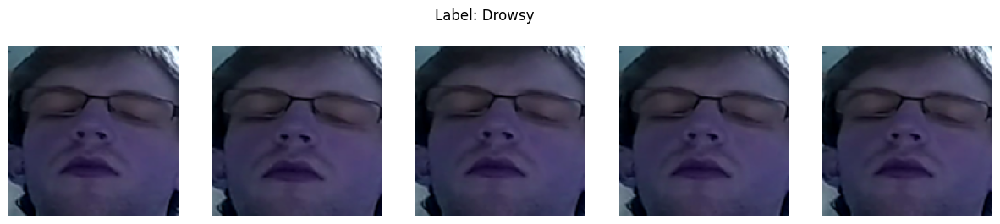

In [10]:
X_sample, y_sample = train_gen[0]

fig, axs = plt.subplots(1, SEQ_LEN, figsize=(15,3))
for i in range(SEQ_LEN):
    axs[i].imshow(X_sample[0][i])
    axs[i].axis('off')

plt.suptitle("Label: " + ("Drowsy" if y_sample[0]==1 else "Non-Drowsy"))
plt.show()

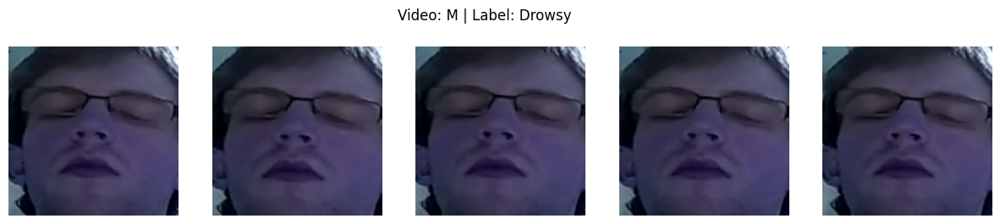

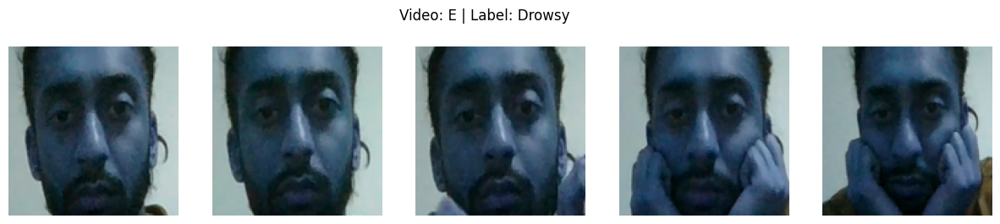

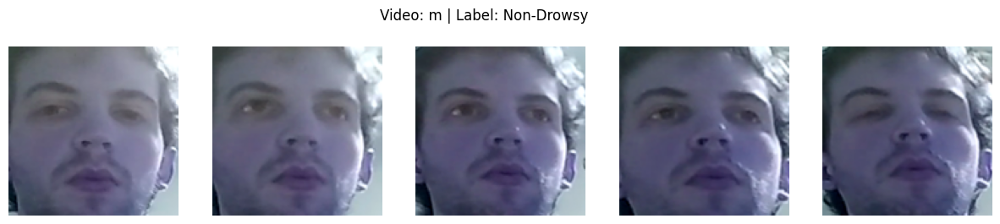

In [16]:
sample_videos = train_data[:3]   # 3 different videos

for prefix, label in sample_videos:
    
    label_folder = "drowsy" if label == 1 else "non_drowsy"
    folder_path = os.path.join(BASE_DIR, label_folder)

    files = sorted([f for f in os.listdir(folder_path) if f.startswith(prefix)])
    
    if len(files) < SEQ_LEN:
        continue

    seq_files = files[:SEQ_LEN]   # first sequence

    frames = []
    for file in seq_files:
        img = cv2.imread(os.path.join(folder_path, file))
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        frames.append(img)

    fig, axs = plt.subplots(1, SEQ_LEN, figsize=(15,3))
    
    for i in range(SEQ_LEN):
        axs[i].imshow(frames[i])
        axs[i].axis('off')

    plt.suptitle(f"Video: {prefix} | Label: " + 
                 ("Drowsy" if label==1 else "Non-Drowsy"))
    plt.show()

In [11]:
model = Sequential()

model.add(TimeDistributed(Conv2D(16, (3,3), activation='relu'),
                          input_shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE, CHANNELS)))
model.add(TimeDistributed(MaxPooling2D(2,2)))

model.add(TimeDistributed(Conv2D(32, (3,3), activation='relu')))
model.add(TimeDistributed(MaxPooling2D(2,2)))

model.add(TimeDistributed(Conv2D(64, (3,3), activation='relu')))
model.add(TimeDistributed(MaxPooling2D(2,2)))

model.add(TimeDistributed(Flatten()))

model.add(LSTM(64))
model.add(Dropout(0.5))

model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/home/anirbannayak/DL_PROJECT/dl-venv/lib/python3.10/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1775369285.229459   12512 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775369287.343933   12347 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 5, 126, 126,    │           448 │
│ (TimeDistributed)               │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 63, 63, 16)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 5, 61, 61, 32)  │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 5, 30, 30, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 5, 28, 28, 64)  │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 5, 14, 14, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 5, 12544)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │     3,227,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,253,601 (12.41 MB)

 Trainable params: 3,253,601 (12.41 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

/home/anirbannayak/DL_PROJECT/dl-venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1775369309.102800   12347 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


7389/7389 ━━━━━━━━━━━━━━━━━━━━ 1390s 188ms/step - accuracy: 0.5347 - loss: 0.7026 - val_accuracy: 0.2567 - val_loss: 0.7310
Epoch 2/10
7389/7389 ━━━━━━━━━━━━━━━━━━━━ 1317s 178ms/step - accuracy: 0.5480 - loss: 0.6904 - val_accuracy: 0.2567 - val_loss: 0.7419
Epoch 3/10
7389/7389 ━━━━━━━━━━━━━━━━━━━━ 1321s 179ms/step - accuracy: 0.5507 - loss: 0.6890 - val_accuracy: 0.2567 - val_loss: 0.7360
Epoch 4/10
7389/7389 ━━━━━━━━━━━━━━━━━━━━ 1319s 179ms/step - accuracy: 0.5498 - loss: 0.6885 - val_accuracy: 0.2567 - val_loss: 0.7466
Epoch 5/10
7389/7389 ━━━━━━━━━━━━━━━━━━━━ 1315s 178ms/step - accuracy: 0.5511 - loss: 0.6881 - val_accuracy: 0.2567 - val_loss: 0.7476
Epoch 6/10
7389/7389 ━━━━━━━━━━━━━━━━━━━━ 1321s 179ms/step - accuracy: 0.5511 - loss: 0.6882 - val_accuracy: 0.2567 - val_loss: 0.7468
Epoch 7/10
7389/7389 ━━━━━━━━━━━━━━━━━━━━ 1322s 179ms/step - accuracy: 0.5511 - loss: 0.6881 - val_accuracy: 0.2567 - val_loss: 0.7570
Epoch 8/10
7389/7389 ━━━━━━━━━━━━━━━━━━━━ 1320s 179ms/step - accur

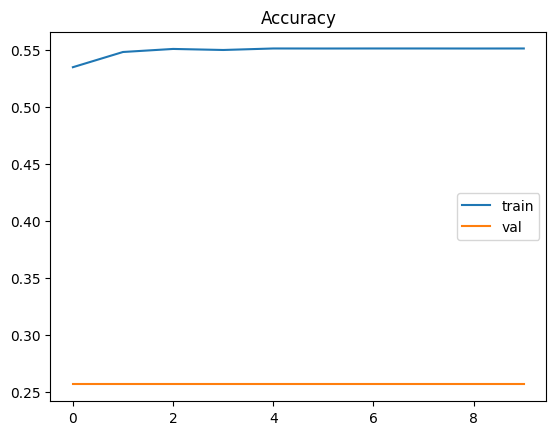

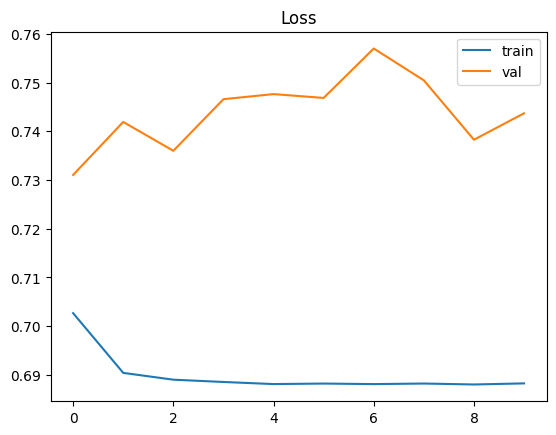

In [13]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

In [14]:
loss, acc = model.evaluate(test_gen)
print("Test Accuracy:", acc)

1841/1841 ━━━━━━━━━━━━━━━━━━━━ 150s 81ms/step - accuracy: 0.6313 - loss: 0.6727
Test Accuracy: 0.6313145160675049


Confusion Matrix:
 [[   0 2715]
 [   0 4649]]


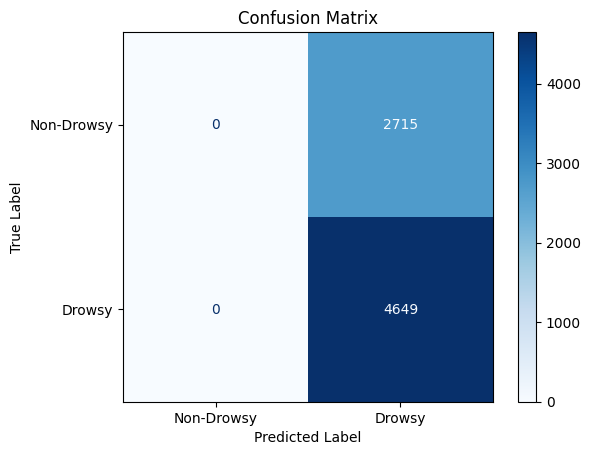

In [17]:
y_true = []
y_pred = []

for i in range(len(test_gen)):
    X_batch, y_batch = test_gen[i]

    preds = model.predict(X_batch, verbose=0)
    preds = (preds > 0.5).astype(int).flatten()

    y_true.extend(y_batch.astype(int))
    y_pred.extend(preds)

# Convert to numpy
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Drowsy", "Drowsy"]
)

disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [19]:
def get_video_sequences(prefix, label):
    
    label_folder = "drowsy" if label == 1 else "non_drowsy"
    folder_path = os.path.join(BASE_DIR, label_folder)

    files = sorted([f for f in os.listdir(folder_path) if f.startswith(prefix)])
    
    sequences = []

    for i in range(len(files) - SEQ_LEN + 1):
        seq_files = files[i:i+SEQ_LEN]
        
        frames = []
        for file in seq_files:
            img = cv2.imread(os.path.join(folder_path, file))
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0
            frames.append(img)
        
        sequences.append(np.array(frames))
    
    return sequences

In [20]:
sample_videos = test_data[:5]   # 5 different videos



========== VIDEO 1: h ==========


/home/anirbannayak/DL_PROJECT/dl-venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


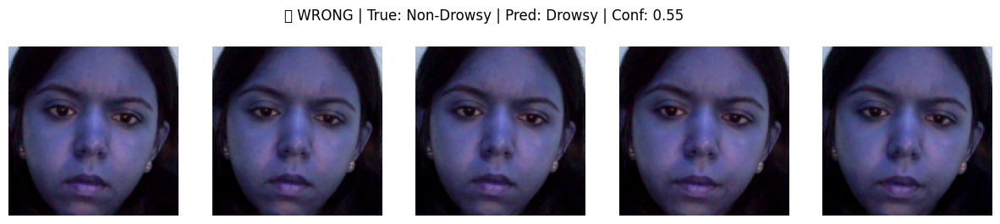

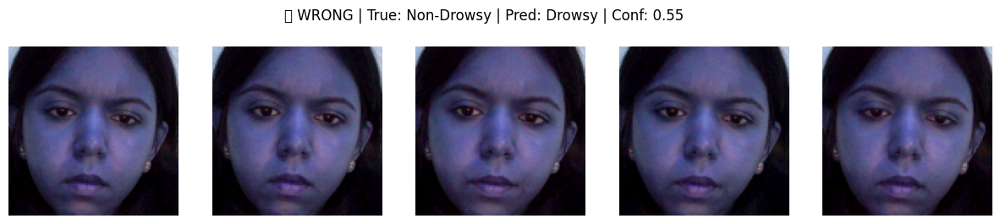

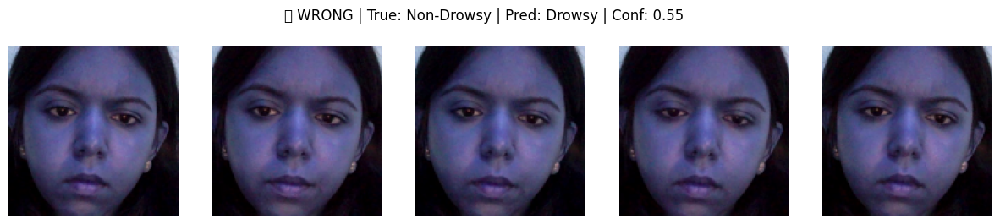

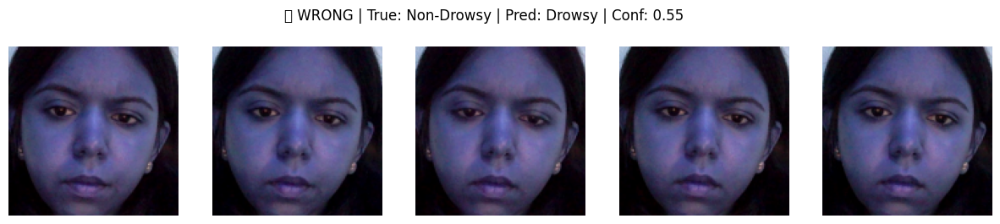

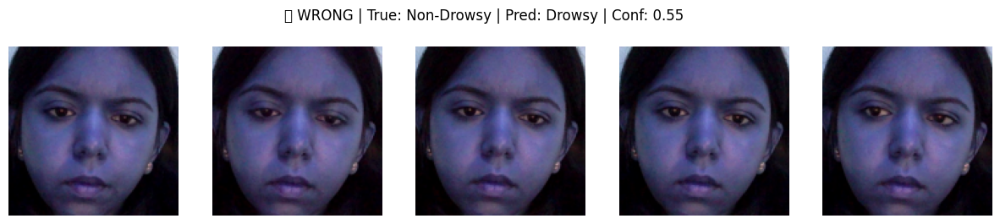


========== VIDEO 2: o ==========


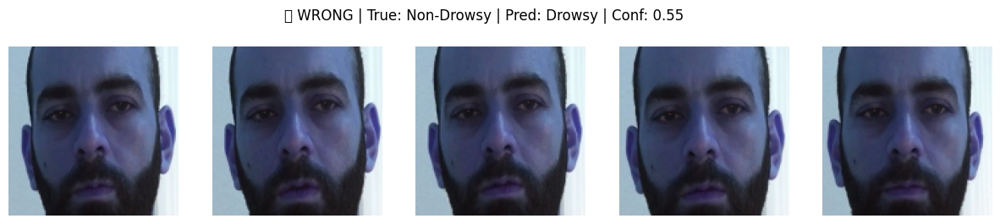

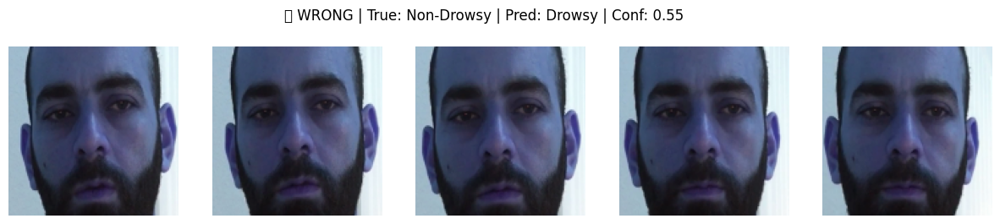

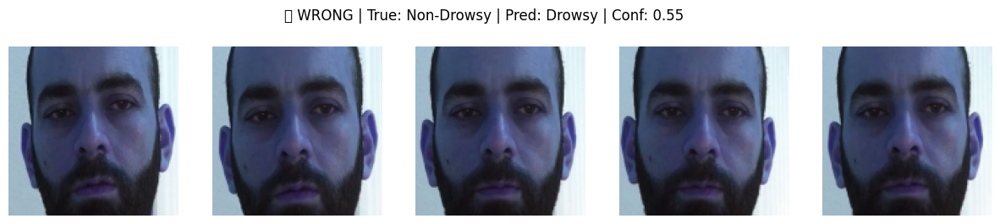

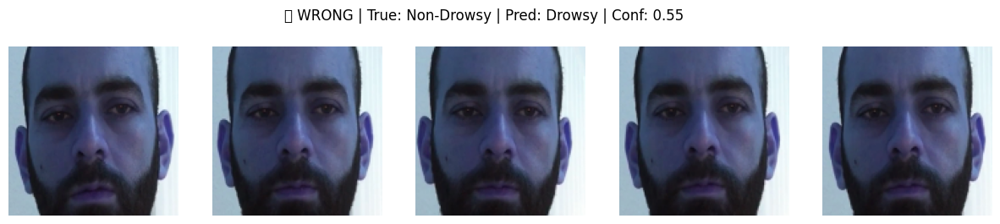

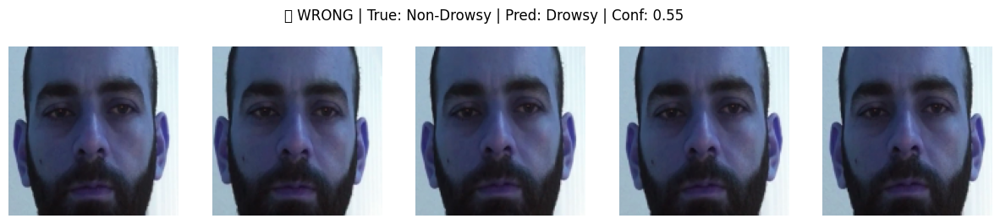


========== VIDEO 3: y ==========


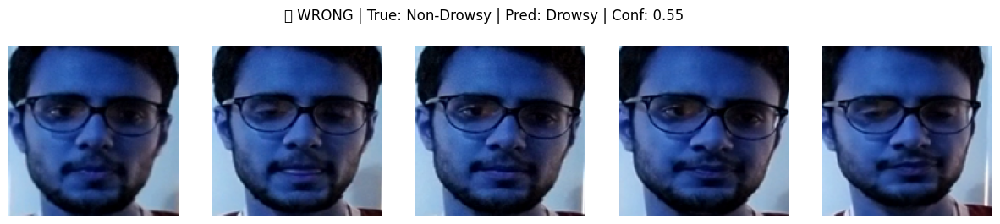

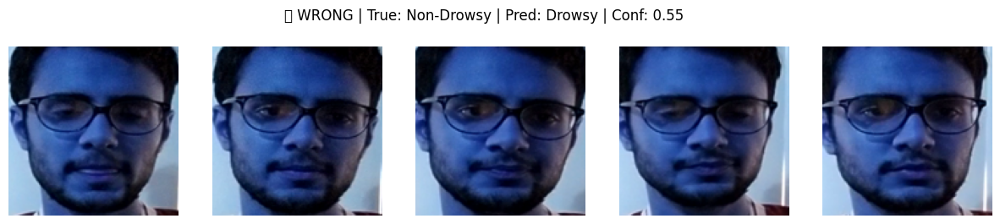

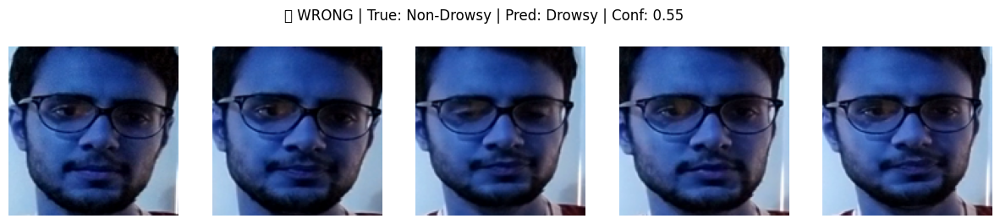

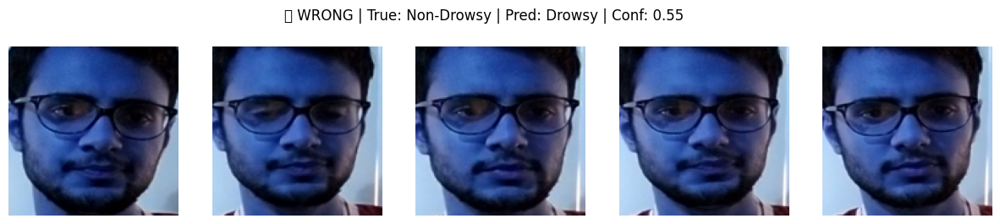

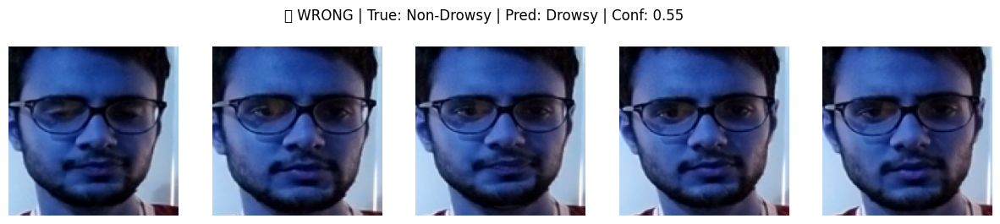


========== VIDEO 4: N ==========


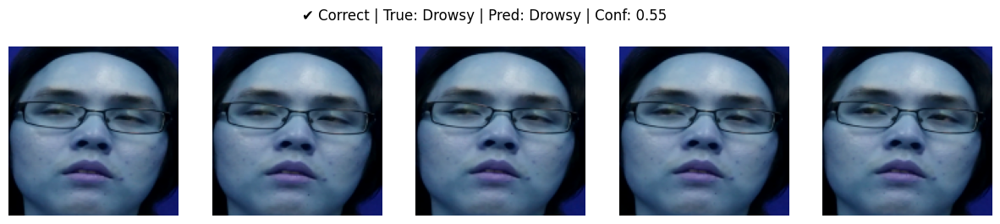

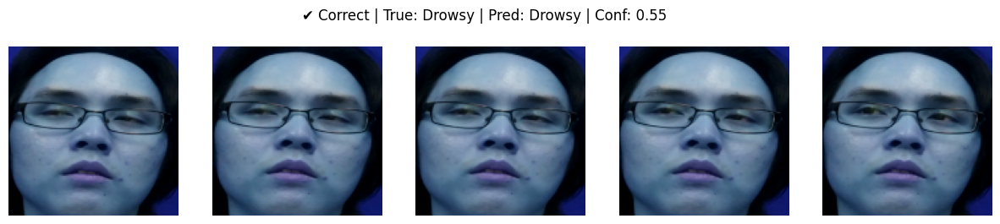

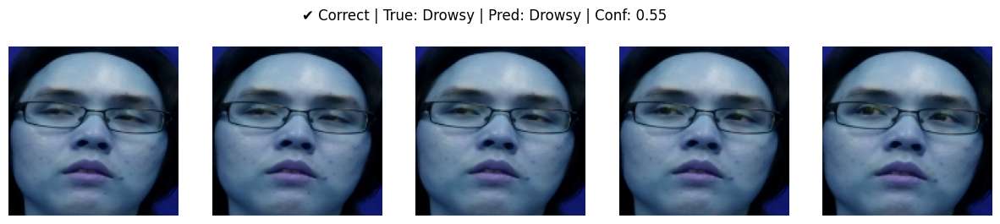

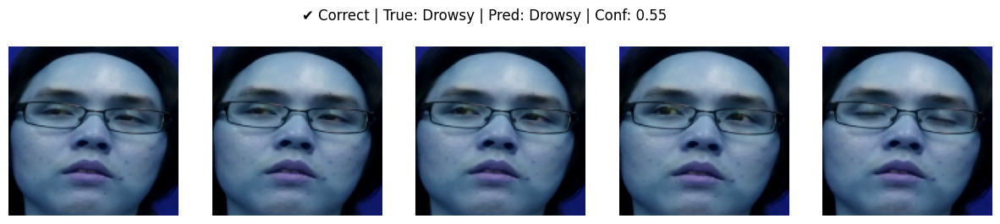

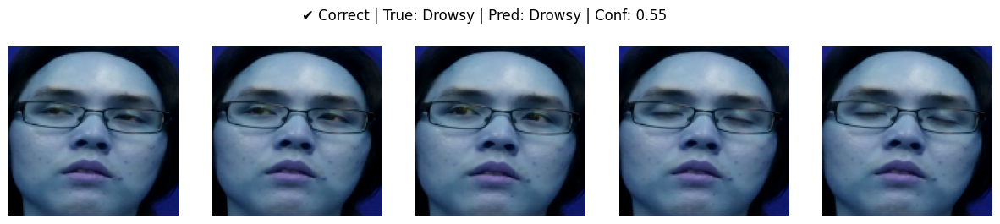


========== VIDEO 5: Z ==========


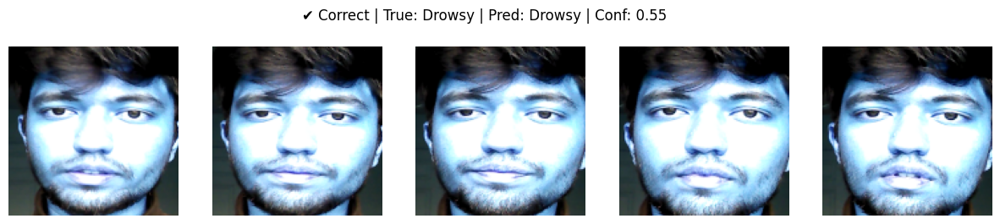

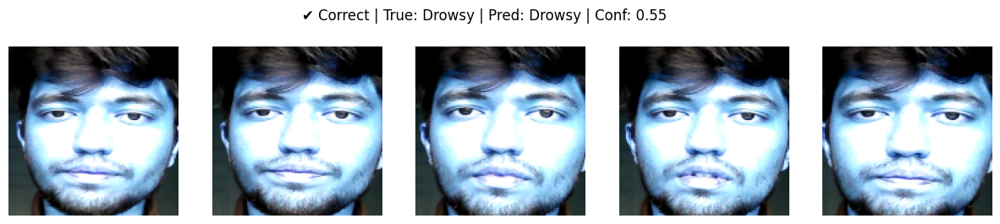

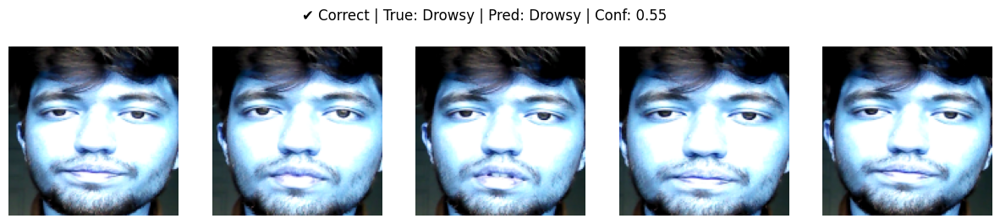

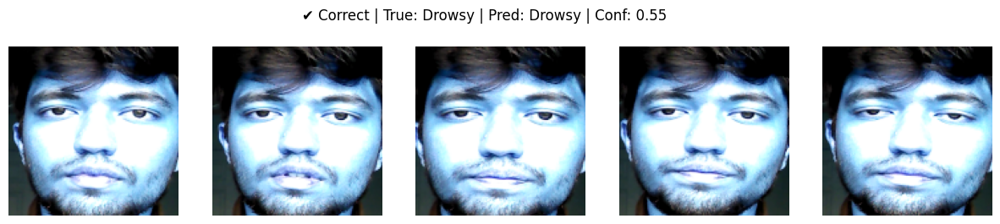

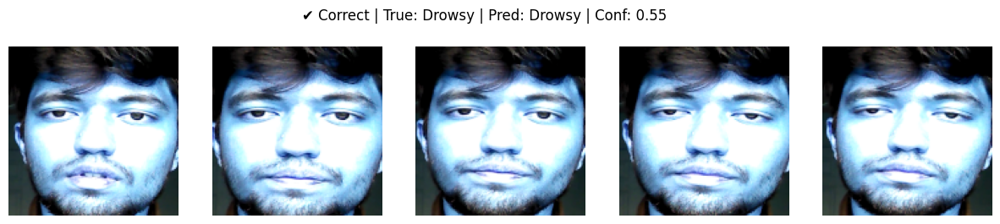

In [21]:
wrong_count = 0

for vid_idx, (prefix, label) in enumerate(sample_videos):

    print(f"\n========== VIDEO {vid_idx+1}: {prefix} ==========")
    
    sequences = get_video_sequences(prefix, label)
    
    if len(sequences) < 5:
        print("Not enough sequences, skipping...")
        continue

    sequences = sequences[:5]   # take first 5 sequences
    
    X_input = np.array(sequences)
    
    preds_prob = model.predict(X_input, verbose=0).flatten()
    preds = (preds_prob > 0.5).astype(int)

    for seq_idx in range(5):

        fig, axs = plt.subplots(1, SEQ_LEN, figsize=(15,3))
        
        for i in range(SEQ_LEN):
            axs[i].imshow(sequences[seq_idx][i])
            axs[i].axis('off')

        true_label = "Drowsy" if label == 1 else "Non-Drowsy"
        pred_label = "Drowsy" if preds[seq_idx] == 1 else "Non-Drowsy"

        # Mark wrong predictions
        if preds[seq_idx] != label:
            wrong_count += 1
            title = f"❌ WRONG | True: {true_label} | Pred: {pred_label} | Conf: {preds_prob[seq_idx]:.2f}"
        else:
            title = f"✔ Correct | True: {true_label} | Pred: {pred_label} | Conf: {preds_prob[seq_idx]:.2f}"

        plt.suptitle(title)
        plt.show()